In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2.0,2.0,1,4.0,West,Relatively New,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2.0,2.0,1,1.0,West,Old Property,NaN,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2.0,2.0,2,2.0,NaN,Undefined,NaN,NaN,1200.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
3,4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2.0,2.0,3,5.0,NaN,Under Construction,1345.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,flat,signature global infinity mall,sector 36,0.41,6269.0,654.0,Built Up area: 654 (60.76 sq.m.),2.0,2.0,3,3.0,NaN,Undefined,NaN,654.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1029
agePossession             0
super_built_up_area    1720
built_up_area          1977
carpet_area            1737
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

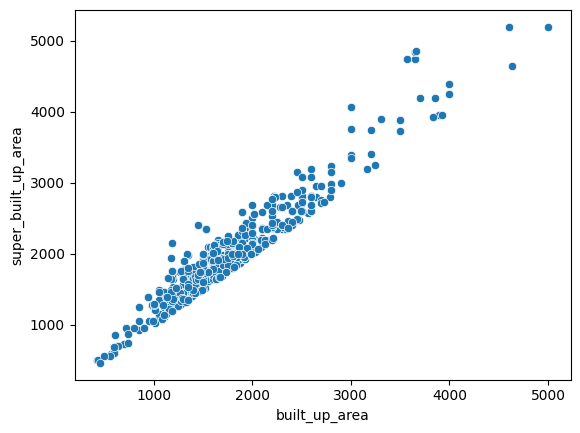

In [8]:
sns.scatterplot(x=df['built_up_area'], y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

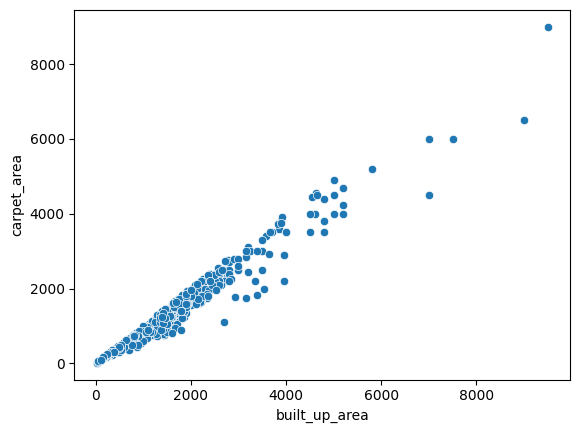

In [9]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [10]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3584    False
3585    False
3586    False
3587    False
3588    False
Length: 3589, dtype: bool

In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(529, 24)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [14]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [15]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [16]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [17]:
sbc_df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
29,31,flat,bhawna cghs,sector 43,3.2500,10156.0,3200.0,Super Built up area 3200(297.29 sq.m.)Carpet a...,4.0,4.0,3+,12.0,NaN,Moderately Old,3200.0,NaN,3000.0,0.0,0.0,0.0,1.0,0.0,0.0,119.0
34,36,flat,chintels paradiso,sector 109,1.8000,8867.0,2030.0,Super Built up area 2030(188.59 sq.m.)Carpet a...,3.0,3.0,2,0.0,East,Moderately Old,2030.0,NaN,1785.0,0.0,1.0,0.0,0.0,0.0,1.0,83.0
35,37,flat,breez global hill view,sohna road,0.2999,5404.0,555.0,Super Built up area 655(60.85 sq.m.)Carpet are...,2.0,2.0,2,6.0,North-East,New Property,655.0,NaN,555.0,0.0,0.0,0.0,0.0,0.0,1.0,109.0
56,58,flat,silverglades the melia,sohna road,1.0100,6999.0,1443.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,2.0,2.0,3,12.0,NaN,Undefined,1450.0,NaN,950.0,1.0,0.0,0.0,0.0,0.0,1.0,80.0
58,60,flat,umang winter hills,sector 77,0.9900,7857.0,1260.0,Super Built up area 1260(117.06 sq.m.)Carpet a...,2.0,2.0,2,1.0,North,Relatively New,1260.0,NaN,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,97.0


In [18]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\barga\AppData\Local\Temp\ipykernel_29800\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\barga\AppData\Local\Temp\ipykernel_29800\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [19]:
df.update(sbc_df)

In [20]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1029
agePossession             0
super_built_up_area    1720
built_up_area          1558
carpet_area            1737
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [21]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [22]:
sb_df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3,4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2.0,2.0,3,5.0,NaN,Under Construction,1345.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5,6,flat,the cocoon,dwarka expressway,2.00,13333.0,1500.0,Super Built up area 1500(139.35 sq.m.),3.0,3.0,3,5.0,NaN,New Property,1500.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12,13,flat,godrej,sector 33,0.95,6859.0,1385.0,Super Built up area 1385(128.67 sq.m.),2.0,2.0,3+,3.0,South-East,Under Construction,1385.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13,14,flat,shree vardhman flora,sector 90,0.70,5385.0,1300.0,Super Built up area 1300(120.77 sq.m.),2.0,2.0,3,13.0,NaN,New Property,1300.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,1.0,15.0
17,19,flat,central park flower valley,sector 33,2.20,10476.0,2100.0,Super Built up area 2100(195.1 sq.m.),3.0,3.0,3,12.0,North-East,New Property,2100.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,49.0


In [23]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\barga\AppData\Local\Temp\ipykernel_29800\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\barga\AppData\Local\Temp\ipykernel_29800\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [24]:
df.update(sb_df)

In [25]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1029
agePossession             0
super_built_up_area    1720
built_up_area           685
carpet_area            1737
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [26]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [27]:
c_df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2.0,2.0,1,4.0,West,Relatively New,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2.0,2.0,1,1.0,West,Old Property,NaN,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2.0,2.0,2,2.0,NaN,Undefined,NaN,NaN,1200.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
6,7,flat,ats triumph,sector 104,1.80,7860.0,2290.0,Carpet area: 2290 (212.75 sq.m.),3.0,4.0,3,14.0,NaN,New Property,NaN,NaN,2290.0,0.0,0.0,0.0,0.0,0.0,1.0,60.0
9,10,flat,signature global city 81,sector 81,0.96,9766.0,983.0,Carpet area: 1075 (99.87 sq.m.),2.0,2.0,2,1.0,NaN,Undefined,NaN,NaN,1075.0,0.0,0.0,0.0,0.0,0.0,1.0,49.0


In [28]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\barga\AppData\Local\Temp\ipykernel_29800\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\barga\AppData\Local\Temp\ipykernel_29800\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [29]:
df.update(c_df)

In [30]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1029
agePossession             0
super_built_up_area    1720
built_up_area             0
carpet_area            1737
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

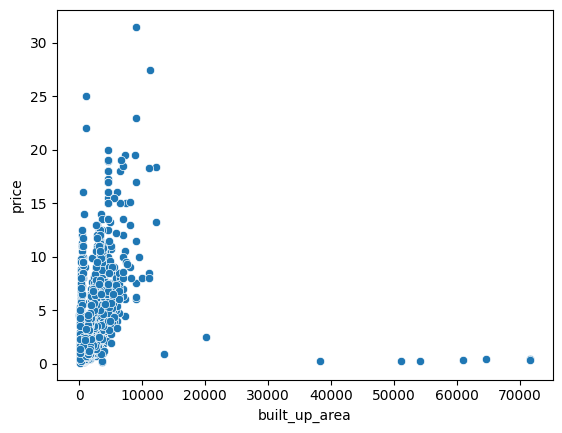

In [32]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [33]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [34]:
anamoly_df.sample(5)

,price,area,built_up_area
3395,4.31,1350.0,1350.0
3353,12.50,3060.0,410.0
1239,3.95,2343.0,1900.0
3346,3.00,1557.0,1557.0
1745,2.60,1711.0,1548.0


In [35]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [36]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

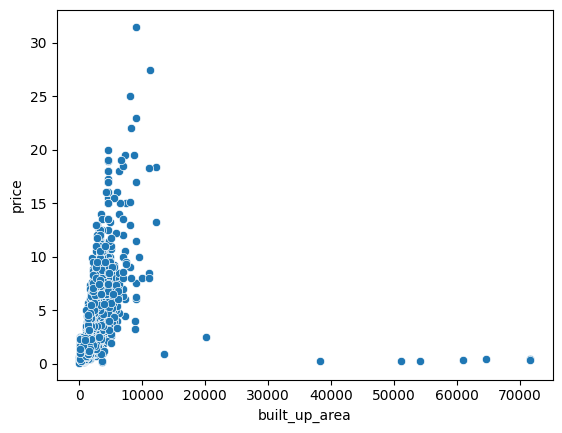

In [38]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [42]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area'],inplace=True)

In [44]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,2.0,2.0,1,4.0,West,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,apna enclave,sector 3,0.50,7692.0,2.0,2.0,1,1.0,West,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,smart world orchard,sector 61,1.47,12250.0,2.0,2.0,2,2.0,NaN,Undefined,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
3,4,flat,parkwood westend,sector 92,0.70,5204.0,2.0,2.0,3,5.0,NaN,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,flat,signature global infinity mall,sector 36,0.41,6269.0,2.0,2.0,3,3.0,NaN,Undefined,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [45]:
df.isnull().sum()

Unnamed: 0            0
property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1029
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [46]:
df[df['floorNum'].isnull()]

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
168,172,flat,experion heartsong,dwarka expressway,1.08,6150.0,3.0,3.0,0,NaN,NaN,Under Construction,1758.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2573,2711,flat,NaN,sector 78,0.60,3692.0,2.0,2.0,0,NaN,NaN,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2821,2964,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,2,NaN,East,Moderately Old,3240.0,0.0,1.0,1.0,1.0,0.0,1.0,88.0
2840,2989,house,independent,sector 2,5.60,17284.0,8.0,6.0,3+,NaN,South-West,Moderately Old,3240.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0
2912,3065,house,independent,sector 24,1.45,2984.0,3.0,3.0,1,NaN,NaN,Old Property,540.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0
2948,3102,house,independent,sector 3,1.50,10288.0,3.0,3.0,0,NaN,NaN,Old Property,210.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2963,3117,house,independent,sector 4,4.12,8889.0,2.0,1.0,3+,NaN,NaN,Moderately Old,4635.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3016,3173,house,independent,sector 4,0.65,11111.0,4.0,2.0,2,NaN,NaN,Moderately Old,585.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3032,3189,house,ansal sushant lok plots,sector 43,3.30,26570.0,1.0,1.0,0,NaN,NaN,Under Construction,1242.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3159,3325,house,jacob pura,sector 12,0.35,9722.0,2.0,1.0,0,NaN,NaN,Old Property,360.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [47]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [48]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\barga\AppData\Local\Temp\ipykernel_29800\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [49]:
df.isnull().sum()

Unnamed: 0            0
property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1029
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [50]:
1011/df.shape[0]

0.28169406519921986

### facing

<Axes: ylabel='count'>

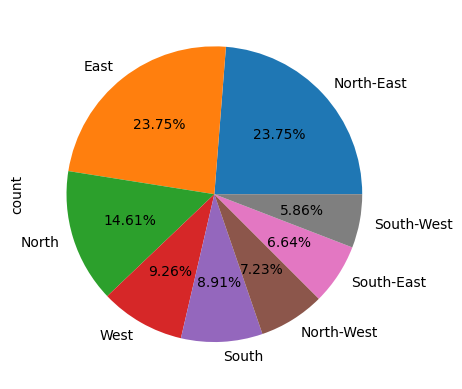

In [51]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [52]:
df.drop(columns=['facing'],inplace=True)

In [53]:
df.sample(5)

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1947,1979,flat,central park 2 bellevue,sector 48,5.0000,11628.0,3.0,4.0,3,14.0,Moderately Old,4778.0,0.0,0.0,0.0,0.0,0.0,1.0,82.0
2067,2099,flat,signature global superbia,sector 95,0.4000,6723.0,2.0,2.0,3,2.0,Undefined,661.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1383,1412,flat,adani m2k oyster grande,sector 102,2.6100,10046.0,3.0,3.0,3,14.0,Relatively New,2200.0,1.0,1.0,0.0,0.0,0.0,1.0,21.0
1876,1907,flat,eldeco accolade,sohna road,0.8692,5966.0,2.0,2.0,3+,10.0,Relatively New,1131.0,1.0,0.0,0.0,0.0,0.0,1.0,72.0
3388,3575,house,emaar mgf marbella,sector 66,18.0000,40000.0,5.0,6.0,3+,3.0,Relatively New,4500.0,1.0,1.0,1.0,1.0,0.0,2.0,153.0


In [54]:
df.isnull().sum()

Unnamed: 0         0
property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [55]:
df.drop(index=[2536],inplace=True)

In [56]:
df.isnull().sum()

Unnamed: 0         0
property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [57]:
df['agePossession'].value_counts()

agePossession
Relatively New        1614
New Property           560
Moderately Old         548
Undefined              436
Old Property           297
Under Construction     133
Name: count, dtype: int64

In [58]:
df[df['agePossession'] == 'Undefined']

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,3,flat,smart world orchard,sector 61,1.47,12250.0,2.0,2.0,2,2.0,Undefined,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
4,5,flat,signature global infinity mall,sector 36,0.41,6269.0,2.0,2.0,3,3.0,Undefined,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,9,flat,raheja revanta,sector 78,4.75,16886.0,3.0,3.0,2,31.0,Undefined,2813.0,0.0,1.0,0.0,0.0,0.0,1.0,100.0
9,10,flat,signature global city 81,sector 81,0.96,9766.0,2.0,2.0,2,1.0,Undefined,1194.0,0.0,0.0,0.0,0.0,0.0,1.0,49.0
14,15,flat,sobha city,sector 108,3.95,16859.0,4.0,5.0,3,25.0,Undefined,2343.0,0.0,0.0,0.0,0.0,0.0,1.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3225,3392,house,independent,sector 108,1.34,5000.0,1.0,1.0,0,1.0,Undefined,2680.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3227,3394,house,independent,sector 39,0.34,7556.0,1.0,1.0,1,1.0,Undefined,450.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3228,3395,house,independent,sector 105,9.90,49500.0,2.0,2.0,2,3.0,Undefined,2000.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3230,3397,house,independent,sector 43,2.15,13030.0,1.0,1.0,0,1.0,Undefined,1650.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [59]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [61]:
df['agePossession'].value_counts()

agePossession
Relatively New        1800
New Property           624
Moderately Old         598
Old Property           336
Under Construction     135
Undefined               95
Name: count, dtype: int64

In [62]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [63]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [64]:
df['agePossession'].value_counts()

agePossession
Relatively New        1816
New Property           644
Moderately Old         605
Old Property           347
Under Construction     135
Undefined               41
Name: count, dtype: int64

In [65]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [66]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [67]:
df['agePossession'].value_counts()

agePossession
Relatively New        1832
New Property           644
Moderately Old         630
Old Property           347
Under Construction     135
Name: count, dtype: int64

In [68]:
df.isnull().sum()

Unnamed: 0         0
property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [69]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [70]:
df.shape

(3588, 19)